https://github.com/CarolineMortensen/Group_project_CSS.git

All team members have contributed equally to the project.\
Christine Schütt (s224213)\
Caroline Mortensen (s224173)\
Aleks Gryn (s234828)

# Assignment 2

## Imports

In [6]:
import pickle
import requests
import pandas as pd
import time
from bs4 import BeautifulSoup
import re
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import json
import statistics
import random
from tqdm import tqdm
from multiprocessing import get_context
import multiprocessing as mp
import json
from networkx.readwrite import json_graph
import netwulf as nw
from IPython.display import display, clear_output
import community.community_louvain as community
import seaborn as sns
import ast
from itertools import chain
from collections import Counter
from wordcloud import WordCloud
import itertools

## Part 1: Properties of the real-world network of Computational Social Scientists

> __Exercise: Analyzing Networks through a Random Model__ 
>
>
>
> 1. _Random Network_: Let's start by building a Random Network, acting as a baseline (or ["null model"](https://en.wikipedia.org/wiki/Null_model)) to understand the Computational Social Scientists Network better.  
> * First, calculate the probability (_p_) that makes the expected number of edges in our random network match the actual edge count in the Computational Social Scientists network. Refer to equation 3.2 in your Network Science textbook for guidance. After finding _p_, figure out the average degree (using the given formula). 
> * Now, write a function to generate a Random Network that mirrors the Computational Social Scientists network in terms of node count, using your calculated _p_. Generate a random network by linking nodes in every possible pair with probability _p_. **Hint**: you can use the function [``np.random.uniform``](https://numpy.org/doc/stable/reference/random/generated/numpy.random.uniform.html) to draw samples from a uniform probability distribution.   
> * Visualize the network as you did for the Computational Social Scientists network in the exercise above (my version is below). 
>
> * Answer the following questions __(max 200 words in total)__: 
>    - What regime does your random network fall into? Is it above or below the critical threshold?  
>    - According to the textbook, what does the network's structure resemble in this regime?  
>    - Based on your visualizations, identify the key differences between the actual and the random networks. Explain whether these differences are consistent with theoretical expectations.
>
>   
> 2. _Shortest Paths_: Here, we will check if the Computational Social Scientists Network exhibits characteristics of a small-world network by analyzing its shortest paths.
> * Begin by identifying the largest connected component within the Computational Social Scientists network. Recall that a connected component is a subset of nodes in which every pair of nodes is connected by a path. For a refresher on connected components, see section 2.9 of the Network Science book. Follow these steps:
>    - Utilize [``nx.algorithms.connected_components``](https://networkx.org/documentation/stable//reference/algorithms/generated/networkx.algorithms.components.connected_components.html) to enumerate all connected components, which will be returned as a list of node subsets.
>    - Select the largest subset of nodes identified in the previous step. Then, create a subgraph of your original network that includes only these nodes, using [``nx.Graph.subgraph``](https://networkx.org/documentation/stable/reference/classes/generated/networkx.Graph.subgraph.html). This subset forms your largest connected component, sometimes referred to as the [giant component](https://en.wikipedia.org/wiki/Giant_component).
> * Calculate the average (unweighted) shortest path length within this giant component by employing [``nx.average_shortest_path_length``](https://networkx.org/documentation/networkx-1.3/reference/generated/networkx.average_shortest_path_length.html).
> * Perform the same calculation for the giant component of the random network you constructed in the above exercise 1.
> * Reflect on how the average shortest path lengths of the real and random networks compare and answer the following questions, supporting your answers with the theory from the book.
>   - Why do you think I asked you to consider the giant component only?
>   - Why do you think I asked you to consider unweighted edges?
>   - Does the Computational Social Scientists network exhibit the small-world phenomenon?

#### Random Network

In [36]:
# Load the JSON file
with open("authors_graph.json", "r") as f:
    data = json.load(f)

# Convert JSON data to a NetworkX graph
authors_graph = json_graph.node_link_graph(data)

# Get number of nodes and edges
N = authors_graph.number_of_nodes()
L = authors_graph.number_of_edges()

print(f"Number of nodes (N): {N}")
print(f"Number of edges (L): {L}")

Number of nodes (N): 17995
Number of edges (L): 57932


In [37]:
# Calculate the probability
p = (2 * L) / (N * (N - 1))

# Compute the average degree
avg_degree = p * (N - 1)

print(f'CSS Network: Calculated probability: {p}')
print(f'CSS Network: Calculated average degree: {avg_degree}')

CSS Network: Calculated probability: 0.00035782357510235496
CSS Network: Calculated average degree: 6.438677410391775


In [7]:
# Generate a random network
def generate_random_network(Nodes=10, p=0.1):
    G = nx.Graph()
    G.add_nodes_from(range(Nodes))
    for i, j in itertools.combinations(range(Nodes), 2):
        if np.random.uniform() < p:
            G.add_edge(i, j)
    return G

# Create a random network
random_network = generate_random_network(N, p)

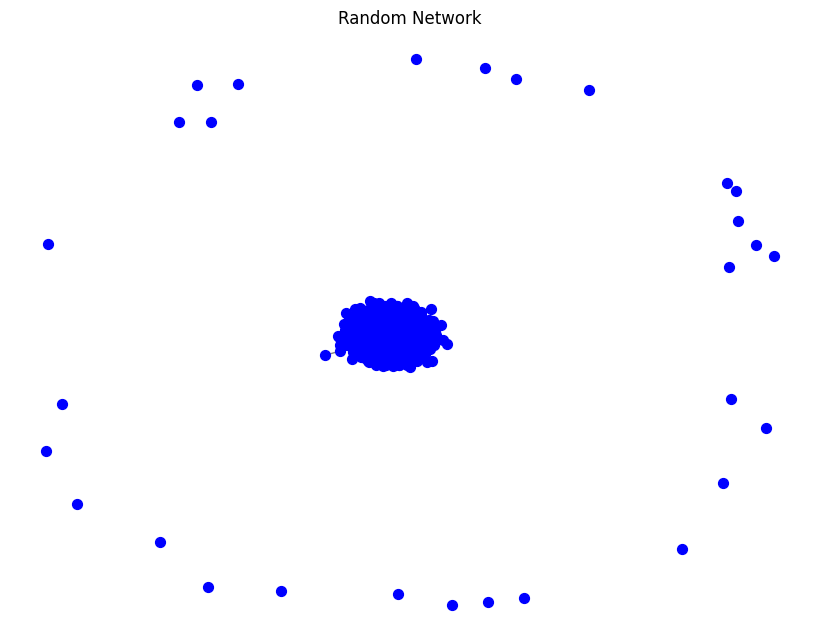

In [ ]:
# Visualize the network
plt.figure(figsize=(8,6))
nx.draw(random_network, node_size=50, node_color='blue', edge_color='gray')
plt.title('Random Network')
plt.show()

In [ ]:
Nr = random_network.number_of_nodes()
Lr = random_network.number_of_edges()

# Calculate the probability of the random network
pr = (2 * Lr) / (Nr * (Nr - 1))

# Compute the average degree of the random network
avg_degree_r = pr * (Nr - 1)

print(f'Random Network: Calculated probability: {pr} < {np.log(Nr)/Nr}')
print(f'Random Network: Calculated average degree: {avg_degree_r} < {np.log(Nr)}')

Random Network: Calculated probability: 0.0003593491986446163 < 0.0005444762000840861
Random Network: Calculated average degree: 6.466129480411226 < 9.79784922051313


True

> * Answer the following questions __(max 200 words in total)__: 
>    - What regime does your random network fall into? Is it above or below the critical threshold?  
>    - According to the textbook, what does the network's structure resemble in this regime?  
>    - Based on your visualizations, identify the key differences between the actual and the random networks. Explain whether these differences are consistent with theoretical expectations.

1. Our random network falls into the supercritical regime, since $ 1 < \langle k_r \rangle < ln(N)$ and $\frac{1}{N} < p_r < \frac{ln(N)}{N} $ . This means most nodes are linked to many others and where the network forms a large, cohesive structure, but some small components may exsits, just like we see in the visualization above. It is above the critical threshold, since the probability of connection is high, meaning the giant component spans most of the network.

2. According to the textbook, a random network in the supercritical regime, resembles a network structure where there's one giant component that connects most of the nodes in a densely connected structure with loops and cycles. With the gian component, a few small isolated components exist in the form of trees. The supercritical regime lasts untill all of the isloated components are absorbed by the giant component.

<!--  with a high connection probability resembles an Erdős-Rényi network in the connected regime. These networks have a poisson degree distribution, meaning most nodes have a similar number of links. They lack hubs (highly connected nodes) and clustering, making them fundamentally different from real-world networks, which often exhibit power-law degree distributions and community structures. -->

3. Though, the avrage degree of the CSS network and randomly generated network may be closely equal, the generated random network does not include realistic mega hubs with many connections that real networks have. If visualized, the Computational Social Scientists network likely has more highly connected hubs and clustering patterns, reflecting real-world collaborations. In contrast, the random network lacks these features, with a more uniform distribution of connections. These differences align with theoretical expectations of random and real networks, as social and collaboration networks often follow small-world and scale-free models rather than purely random connections.

#### Shortest Paths

In [10]:
# Identify the largest connected component
components = list(nx.connected_components(authors_graph))
largest_component = max(components, key=len) # Largest set of nodes

# Create a subgraph containing only the largest component
lcc_graph = authors_graph.subgraph(largest_component).copy()

print(f"Number of nodes in the largest connected component: {lcc_graph.number_of_nodes()}")
print(f"Number of edges in the largest connected component: {lcc_graph.number_of_edges()}")

Number of nodes in the largest connected component: 14571
Number of edges in the largest connected component: 48720


In [11]:
# Compute the average shortest path length
avg_shortest_path_length = nx.average_shortest_path_length(lcc_graph)
print(f"Average Shortest Path Length in CSS network: {avg_shortest_path_length}")

Average Shortest Path Length in CSS network: 5.689819451739564


In [12]:
# Compute for the random network
# Finding the largest connected component in the random network
random_components = list(nx.connected_components(random_network))
largest_random_component = max(random_components, key=len)

In [13]:
# Creating a subgraph for the largest component
random_lcc = random_network.subgraph(largest_random_component).copy()

In [14]:
# Compute the average shortest path length
avg_shortest_path_length_random = nx.average_shortest_path_length(random_lcc)
print(f"Average Shortest Path Length in Random Network: {avg_shortest_path_length_random}")

Average Shortest Path Length in Random Network: 5.463293921849409


In [42]:
np.log(N)

9.79784922051313

> * Reflect on how the average shortest path lengths of the real and random networks compare and answer the following questions, supporting your answers with the theory from the book.
>   - Why do you think I asked you to consider the giant component only?
>   - Why do you think I asked you to consider unweighted edges?
>   - Does the Computational Social Scientists network exhibit the small-world phenomenon?

1. The giant component represents the largest set of nodes that are connected, ensuring that every node in the subgraph is reachable from every other node. If we included isolated nodes or small disconnected components, they would skew metrics like the shortest path length, making them meaningless for network-wide analysis. The formula $ \langle d \rangle = \frac{ln(N)}{ln(\langle k \rangle)}$, assumes all nodes can be reached, to pose any meaning.

2. Unweighted shortest path length gives a clearer measure of the network’s connectivity rather than the intensity of the connections, which could vary based on arbitrary factors like collaboration strength or citation counts. What matters for our shortest path calculations is if theres a link present between the nodes. 

3. The avrage shortest path formula for a random network given: $ \langle d \rangle = \frac{ln(N)}{ln(\langle k \rangle)}$ works as a baseline for our evaluation of the small world phenomenon. According to the small-world theory, a real network exhibits small-world properties if its average shortest path length is significantly lower than that of an equally random network, which typically scales logarithmically with the number of nodes, $ln(N)$. We see that the real network actually has a higher avrage shortest path length than the random network, and does therefore suggest that it doesn't exhibit the small-world phenomenon. The reasoning could be that most researchers collaborate in small sub-clusters and only some few researchers, that are highly connected to a large amount of people, is the only connection between all the clusters. Hence the connectivity between all the reasearchers have to traverse through those hubs, which tends to be longer, than a scenario where the researchers collaborated with a broader reach of people.

## Part 2: Network Analysis in Computational Social Science

> __Exercise 1: Mixing Patterns and Assortativity__ 
>
> __Part 1: Assortativity Coefficient__ 
> 1. *Calculate the Assortativity Coefficient* for the network based on the country of each node. Implement the calculation using the formula provided during the lecture, also available in [this paper](https://arxiv.org/pdf/cond-mat/0209450.pdf) (equation 2, here for directed networks). **Do not use the NetworkX implementation.**
>
> __Part 2: Configuration model__
> In the following, we are going to assess the significance of the assortativity by comparing the network's assortativity coefficient against that of random networks generated through the configuration model.  
>
> 2. *Implement the configuration model* using the _double edge swap_ algorithm to generate random networks. Ensure each node retains its original degree but with altered connections. Create a function that does that by following these steps:
>   - **a.** Create an exact copy of your original network.
>   - **b.** Select two edges, $e_{1} = (u,v)$ and $e_{2} = (x,y)$, ensuring *u != y* and *v != x*.
>   - **c.** Flip the direction of $e_{1}$ to $e_{1} = (v,u)$ 50% of the time. This ensure that your final results is not biased, in case your edges were sorted (they usually are). 
>   - **d.** Ensure that new edges $e_{1}' = (e_{1}[0],e_{2}[1])$ and $e_{2}' = (e_{2}[0],e_{1}[1])$ do not already exist in the network.
>   - **e.** Remove edges $e_{1}$ and $e_{2}$ and add edges $e_{1}'$ and $e_{2}'$.
>   - **f.** Repeat steps **b** to **e** until you have performed _E*10_ swaps, where E is the total number of edges.
> 3. *Double check that your algorithm works well*, by showing that the degree of nodes in the original network and the new 'randomized' version of the network are the same.
>
>
> __Part 3: Analyzing Assortativity in Random Networks__  
>
> 4. *Generate and analyze at least 100 random networks* using the configuration model. For each, calculate the assortativity with respect to the country and plot the distribution of these values. Compare the results with the assortativity of your original network to determine if connections within the same country are significantly higher than chance.
>

## Part 1

Opening the data, and inspecting how the data is structured

In [25]:
# Load the JSON file
with open('authors_graph.json') as f:
    data = json.load(f)
    G = nx.node_link_graph(data)

In [26]:
#checking the import and data structure
print(G.nodes()['A5009041563'])
print(data.keys())

countries = [data["country"] for _, data in G.nodes(data=True)] #how do i access countries

{'display_name': 'Richard Kim', 'country': 'US', 'citations': 3128, 'first_publication': 2018}
dict_keys(['directed', 'multigraph', 'graph', 'nodes', 'links'])


Here two functions are created: "construct_mixing_matrix" and "assort_check" based on the formula provided in the lecture

In [27]:
import networkx as nx
import numpy as np

def construct_mixing_matrix(G, attribute):
    # Get unique categories
    categories = set(nx.get_node_attributes(G, attribute).values())
    category_to_index = {cat: i for i, cat in enumerate(sorted(categories))}
    
    # Initialize mixing matrix
    n = len(categories)
    e = np.zeros((n, n))
    
    # Iterate over edges and count occurrences
    for u, v in G.edges():
        attr_u = G.nodes[u].get(attribute)
        attr_v = G.nodes[v].get(attribute)
        
        if attr_u is not None and attr_v is not None:
            i, j = category_to_index[attr_u], category_to_index[attr_v]
            e[i, j] += 1
            e[j, i] += 1  # Since the graph is undirected

    # Normalize by total number of edges
    e /= e.sum()
    
    return e, category_to_index

def assort_check(G, attribute):
    """Computes the assortativity coefficient for a given attribute in a NetworkX graph."""
    e_matrix, category_map = construct_mixing_matrix(G, attribute)

    a = e_matrix.sum(axis=0)
    b = e_matrix.sum(axis=1)
    eii = np.trace(e_matrix)
    sum_a_b = np.sum(a * b)
    r = (eii - sum_a_b) / (1 - sum_a_b)
    return r


To validate the implementation, the function attribute_assortativity_coefficient is used - it can be seen that the results are approximately equal, and only differs after 5 significant digits.

In [ ]:
# checking the implementation
r = nx.attribute_assortativity_coefficient(G, "country")
print(assort_check(G, "country"))
print(r)

0.3924927824930567
0.3924835122867711


## Part 2

Firstly, the function for doing the doubeswap is created:

In [ ]:
def config_doubleswap(G):
    G2 = G.copy()  # creating a copy of original data
    edgelist = set(G2.edges()) # storing the edges used for mixing
    E = len(G.edges())

    # Select two edges
    for i in tqdm(range(E*10)):
        #loop to only swap if conditions are true
        swap = False
        while not swap:
            e1, e2 = random.sample(list(edgelist), 2)

            # ensuring that e_{1}' = (e_{1}[0],e_{2}[1]) and e_{2}' = (e_{2}[0],e_{1}[1]) does not exist
            if (e1[0] != e2[1]) and (e1[1] != e2[0]) and (e1[0] != e2[0]) and (e1[1] != e2[1]):
                old_e1 = e1
                #random flipping 50% of the time
                if int(np.random.choice([True, False])):
                    e1 = (e1[1], e1[0]) 

                e1_new = (e1[0], e2[1])
                e2_new = (e2[0], e1[1])
                
                # ensuring that the newly constructed edges does not already exist in the graph
                if (e1_new not in G2.edges()) and (e2_new not in G2.edges()) and ((e1_new[0] != e1_new[1]) or (e2_new[0] != e2_new[1])):
                    edgelist.remove(old_e1)
                    edgelist.remove(e2)

                    # Update the edge list to reflect the new graph state
                    edgelist.add(e1_new)
                    edgelist.add(e2_new)

                    # Remove the old edges and add the new ones
                    G2.remove_edges_from([e1, e2])
                    G2.add_edges_from([e1_new, e2_new])
                    swap = True

    return G2

In [ ]:
def check_degree_similarity(N1, N2):
    # Check if the degree distributions of nodes in the original network (N1)
    # are the same as the degree distributions in the randomized network (N2).

    # Get the degree of each node in both networks
    degrees_N1 = [degree for node, degree in N1.degree()]
    degrees_N2 = [degree for node, degree in N2.degree()]
    
    # Count the frequency of each degree in both networks
    degree_count_N1 = Counter(degrees_N1)
    degree_count_N2 = Counter(degrees_N2)
    
    # Compare the degree distributions
    return degree_count_N1 == degree_count_N2 # Outputs True if the configuration retains the original degrees

Ensuring that each node retains its original degree but with altered connections, when running the configuration model, by checking if the degree distribution between the original graph and the configuration is equal. We see that its True for an arbitraty Graph, hence the configuration works.

In [34]:
# Create a random graph with 100 nodes and a probability of edge creation
testGraph = nx.erdos_renyi_graph(100, 0.05)  # 100 nodes, 5% probability of edge creation
testConfiguration = config_doubleswap(testGraph)

check_degree_similarity(testGraph, testConfiguration)

100%|██████████| 2560/2560 [00:00<00:00, 9536.47it/s]


True

In [30]:
shuffled_list = []
shuffled_list

[]

To decrease the run time, the swapping-code is run in parallel using the function below. This is repeated 13 times to obtain over 100 random networks.

In [31]:
def parallel_run(G):
    p = get_context("fork").Pool(8)
    results = p.map(config_doubleswap, [G for _ in range(8)])
    p.close()
    return results

In [32]:
from IPython.display import display, clear_output

In [ ]:
for i in range(13):
    clear_output() 
    shuffled_list += parallel_run(G)
    print(f"Reached nr: {i} ")

with open("100_networks.pkl", "wb") as f:
    pickle.dump(shuffled_list, f)

100%|██████████| 579320/579320 [16:36<00:00, 581.42it/s] 


Reached nr: 0 


100%|██████████| 579320/579320 [17:12<00:00, 560.92it/s] 


Reached nr: 1 


100%|██████████| 579320/579320 [17:13<00:00, 560.28it/s] 


...

Reached nr: 10 


100%|██████████| 579320/579320 [17:19<00:00, 557.14it/s] 


Reached nr: 11 


100%|██████████| 579320/579320 [17:05<00:00, 564.92it/s] 


Reached nr: 12 


In [58]:
#opening the pickle
with open("100_networks.pkl", "rb") as f:
    shuffled_list = pickle.load(f)

To validate the swapping procedure, the degree of the swapped and original network is inspected:

In [62]:
import statistics
means, medians, mins, maxs = [], [], [], []

for i in range(len(shuffled_list)):
    node_degrees = [deg for _, deg in shuffled_list[i].degree()]
    means.append(statistics.mean(node_degrees))
    medians.append(statistics.median(node_degrees))
    mins.append(min(node_degrees))
    maxs.append(max(node_degrees))

org_degree = [deg for _, deg in G.degree()]
print(f"Network degree of shuffled: {statistics.mean(node_degrees)}.")
print(f"Network degree of original: {statistics.mean(org_degree)}.")

Network degree of shuffled: 6.438677410391776.
Network degree of original: 6.438677410391776.


The degree of the shuffled and original network is equal, thus the implementation can be assumed to be correct.

## Part 3
The results should be compared with the assortativity of the original network to determine if connections within the same country are significantly higher than chance.

In [54]:
network_density2, assort_shuffled = [], []
for i in range(len(shuffled_list)):
    network_density2.append(nx.density(shuffled_list[i]))
    assort_shuffled.append(assort_check(shuffled_list[i], "country"))

assort_org = assort_check(G, "country")
network_density = nx.density(G)
print(f"Mean network density of shuffled: {statistics.mean(network_density2)}.")
print(f"Network density of original: {network_density}.")

print(f"Mean network assortivity of shuffled: {statistics.mean(assort_shuffled)}.")
print(f"Network assortivity of original: {assort_org}.")

Mean network density of shuffled: 0.00035782357510235496.
Network density of original: 0.00035782357510235496.
Mean network assortivity of shuffled: -5.250815760309933e-05.
Network assortivity of original: 0.3924927824930567.


To gain an initial idea of if the connections within the same country is significally higher than chance, the mean assortivity of the shuffled networks have a zero mean, which indicates that connections are random. This can also be seen in the plot below:

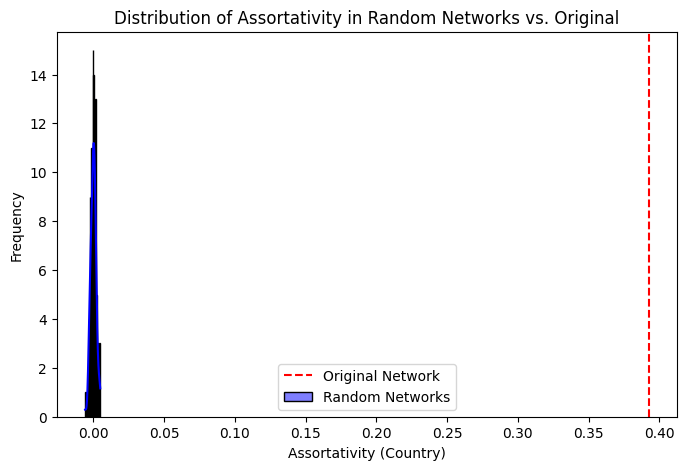

In [55]:
# Plot distribution
plt.figure(figsize=(8, 5))
sns.histplot(assort_shuffled, bins=20, kde=True, color="blue", label="Random Networks")
plt.axvline(assort_org, color="red", linestyle="dashed", label="Original Network")

# Labels and legend
plt.xlabel("Assortativity (Country)")
plt.ylabel("Frequency")
plt.legend()
plt.title("Distribution of Assortativity in Random Networks vs. Original")
plt.show()

The assortivity of the randomized networks roughly follow a gaussian distribution with a zero-mean, whereas the assortivity of the original network is $\approx 0.40$. Had the connections in the original network also been centered around zero, connections would likely have been random, but as assortativity is $\approx 0.40$, the connections within the same country are significally higher than chance. 

> __Exercise 2: Zachary's karate club__: In this exercise, we will work on Zarachy's karate club graph (refer to the Introduction of Chapter 9). The dataset is available in NetworkX, by calling the function [karate_club_graph](https://networkx.org/documentation/stable//auto_examples/graph/plot_karate_club.html)
>
> 1. Visualize the graph. Set the color of each node based on the club split (the information is stored as a node attribute). My version of the visualization is below.
>
> 2. Write a function to compute the __modularity__ of a graph partitioning (use **equation 9.12** in the book). The function should take a networkX Graph and a partitioning as inputs and return the modularity.
> 3. Explain in your own words the concept of _modularity_.
> 4. Compute the modularity of the Karate club split partitioning using the function you just wrote. Note: the Karate club split partitioning is avilable as a [node attribute](https://networkx.org/documentation/networkx-1.10/reference/generated/networkx.classes.function.get_node_attributes.html), called _"club"_.
> 5. Create $1000$ randomized version of the Karate Club network using the _double edge swap_ algorithm you wrote in the exercise above 5. For each of them, compute the modularity of the "club" split and store it in a list.
> 6. Compute the average and standard deviation of the modularity for the random network.
> 7. Plot the distribution of the "random" modularity. Plot the actual modularity of the club split as a vertical line (use [axvline](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.axvline.html)).
> 8. Comment on the figure. Is the club split a good partitioning? Why do you think I asked you to perform a randomization experiment? What is the reason why we preserved the nodes degree?
> 9.  Use [the Python Louvain-algorithm implementation](https://anaconda.org/auto/python-louvain) to find communities in this graph. Report the value of modularity found by the algorithm. Is it higher or lower than what you found above for the club split? What does this comparison reveal?
> 10.  Compare the communities found by the Louvain algorithm with the club split partitioning by creating a matrix **_D_** with dimension (2 times _A_), where _A_ is the number of communities found by Louvain. We set entry _D_(_i_,_j_) to be the number of nodes that community _i_ has in common with group split _j_. The matrix **_D_** is what we call a [**confusion matrix**](https://en.wikipedia.org/wiki/Confusion_matrix). Use the confusion matrix to explain how well the communities you've detected correspond to the club split partitioning.

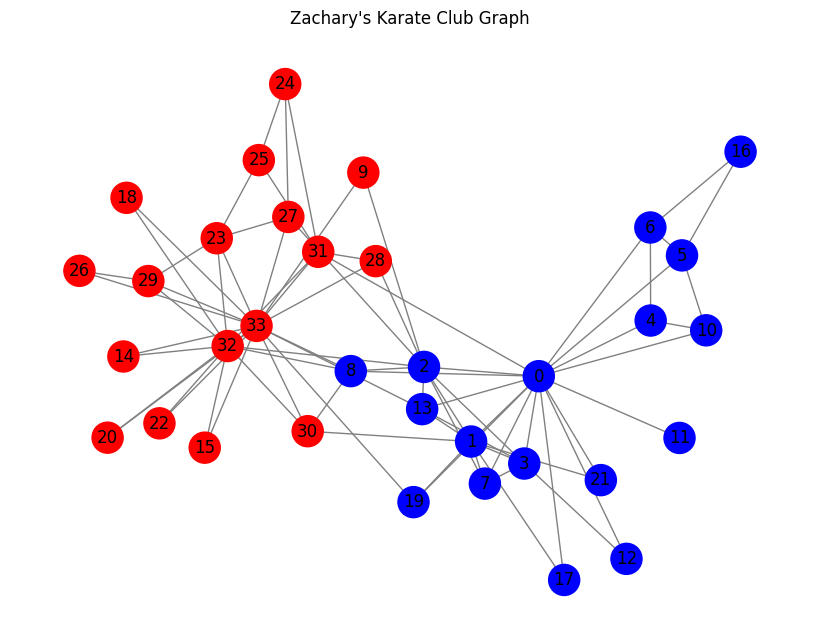

In [3]:
graph = nx.karate_club_graph()

# Get node colors based on the club split
club_colors = {'Mr. Hi': 'blue', 'Officer': 'red'}
node_colors = [club_colors[graph.nodes[n]['club']] for n in graph.nodes]

# Visualizing the Graph
plt.figure(figsize=(8, 6))
nx.draw(graph, with_labels=True, node_color=node_colors, node_size=500, edge_color='gray')
plt.title("Zachary's Karate Club Graph")
plt.show()

In [4]:
### Modularity function, 

def modulatiry(graph, partition):
    # The partition is a dictionary with nodes as key, and a designated partition as value
    L = graph.number_of_edges() # Define number of total edges
    communities = set(partition.values()) # Define partitions of communities
    M = 0 # Initialize modulatiry

    # Equation sum
    for c in communities:
        nodes_in_c = [node for node in graph.nodes if partition[node] == c]
        L_c = graph.subgraph(nodes_in_c).number_of_edges()  # Edges inside community
        k_c = sum(graph.degree(n) for n in nodes_in_c)  # Sum of node degrees
        
        M += (L_c / L) - (k_c / (2 * L))**2  # Modularity formula

    return M

Modularity is a coefficient that calculates how well a partition of nodes is connected. It helps determine whether a group of nodes forms a community. Furthermore, this coefficient evaluates the quality of a partition, as not all partitions are perfect, a higher modularity score implies a better partition, zero modulatiry implies random connectivity and negative modulatiry implies no community. Modularity is a useful method for identifying the best partition in a graph.

One of the main challenges in graph partitioning is that finding the optimal partition through brute-force search becomes computationally expensive, as the time complexity increases exponentially with graph size. Modularity helps address this problem by providing a heuristic to efficiently evaluate and compare different partitions, making it a practical tool in network analysis and community detection.

In [5]:
# Make a partition set of the nodes such that they are assigned to respect of the club
karateclub = nx.karate_club_graph()

# Partition the nodes into either 0 or 1, based on the "club" attribute
partition = {n: 0 if karateclub.nodes[n]['club'] == 'Mr. Hi' else 1 for n in karateclub.nodes} 

print(f"Karate Club Modularity: {modulatiry(karateclub, partition)}") # Compute the modularity of the karate club, with nodes partitioned for each club.

Karate Club Modularity: 0.3582347140039447


In [6]:
def double_edge_swap_raw(N, iter=None):
    G = N.copy() # Copy the existing network

    edges = list(G.edges()) # Get a list of edges in the newtork
    nodes = list(G.nodes()) # Get a list of nodes in the network

    if iter==None:
        max_iterations = 10*len(edges) # Determine times to repeat the double-edge swap (Rule of thumb)
    else:
        max_iterations = iter

    for _ in range(max_iterations):
        # Randomly pick two edges (u, v) and (x, y)
        (u, v), (x, y) = random.sample(edges, 2)

        # Ensure that u != y and v != x
        if u != y and v != x:
            # Flip direction of e1 with 50% probability
            if random.random() < 0.5:
                u, v = v, u  # Flip edge direction of e1
            
            # Define the new edges
            new_edge_1 = (u, y)
            new_edge_2 = (x, v)

            # Ensure that the new edges do not already exist
            if not G.has_edge(new_edge_1[0], new_edge_1[1]) and not G.has_edge(new_edge_2[0], new_edge_2[1]):
                # Remove old edges and add new ones
                G.remove_edge(u, v)
                G.remove_edge(x, y)
                G.add_edge(new_edge_1[0], new_edge_1[1])
                G.add_edge(new_edge_2[0], new_edge_2[1])
                
                # Update the edges list
                edges = list(G.edges())
    
    return G

In [7]:
### 1000 randomized Karate Club configurations

modularity_list = [] # Store modularity values

for i in range(1000):
    clear_output()
    print(f"Progress: {i+1}/1000")

    gn = double_edge_swap_raw(karateclub) # Generated Network
    partition = {n: 0 if gn.nodes[n]['club'] == 'Mr. Hi' else 1 for n in gn.nodes} # Partition the generated network
    m = modulatiry(gn, partition) # Calculate modularity

    modularity_list.append(m) # append to list

Progress: 1000/1000


In [ ]:
print(f"Modularity avrage: {np.mean(modularity_list)}") # Compute mean of the modularity list
print(f"Modularity std: {np.std(modularity_list)}") # Compute std of the modularity list

Modularity avrage: 0.004914526949466905
Modularity std: 0.04849484894103652


In [9]:
def plot_distribution(data, vline, text):
    plt.figure(figsize=(8, 5))
    
    # Plot histogram
    plt.hist(data, bins=30, alpha=0.7, color='blue', edgecolor='black', density=True)
    
    # Add vertical line at the original karate club modularity
    plt.axvline(vline, color='red', linestyle='dashed', linewidth=2, label=f'x = {vline}')
    
    # Labels and title
    plt.xlabel('Value')
    plt.ylabel('Density')
    plt.title(text)
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)
    
    plt.show()

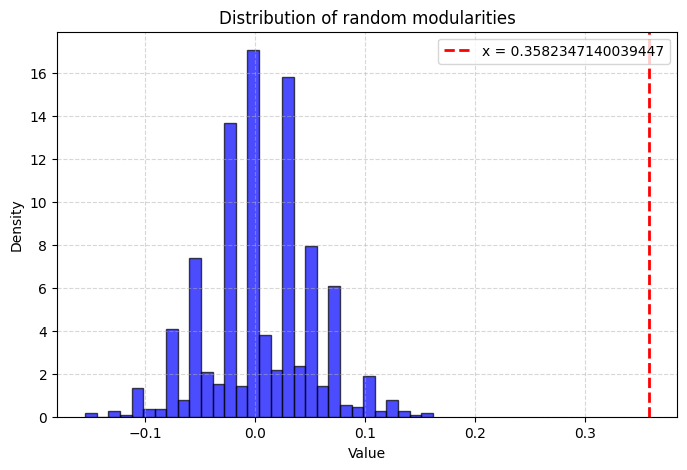

In [ ]:
### Plot modularity distribution
plot_distribution(modularity_list, modulatiry(karateclub, partition), "Distribution of random modularities")

The Club Split itself is a somewhat a good partitioning, as the modularity coefficient is positive around 0.35. 

The random experiment shows us from the figure that the random modularities form a distribution around zero, which modularity wise means that the connectivity in the partitioning is random. We can use this experiment to validate that the modularity of the karate club partitioning captures a real structure in the network and is not just an arbitrary division.

By keeping the degree of each node the same in the randomized networks, we can perhaps control for the degree distribution as a possible explanation for high modularity.

In [ ]:
louvain_partition = community.best_partition(karateclub) # Get the best louvain partition
mod = modulatiry(karateclub,louvain_partition) # Calculate Modularity of the louvain partition
mod_original = modulatiry(karateclub,partition) # Calculate Modularity of the original partition
print("Louvain Modularities")
print(f"Original Partition: {mod_original}")
print(f"Louvain partition: {mod}")

Louvain Modularities
Original Partition: 0.3582347140039447
Louvain partition: 0.4197896120973044


The modularity of the Louvain partition (0.4198) is higher than the modularity of the original club split (0.3582). This suggests that the natural club division is not the most optimal partition in terms of modularity.

In [14]:
# Number of Louvain communities
num_louvain_community = len(set(louvain_partition.values()))

# Confusion matrix: (2 x num_louvain_community)
D = np.zeros((2, num_louvain_community)) # Column = a community detected in the louvain, row = club groups

# Compute confusion matrix
for node in karateclub.nodes:
    club_group = partition[node] # Get row value
    louvain_group = louvain_partition[node] # Get column value
    D[club_group, louvain_group] += 1

print("Confusion Matrix")
print(D)

Confusion Matrix
[[11.  1.  5.  0.]
 [ 0. 11.  0.  6.]]


If we consider the karate club partitioning and the 4 friendgroups. We see from the original that two friend groups of 6 and 12 are partitioned into one club and two friend groups of 11 and 5 are partitioned into the other club. We see that the Louvain partition is able to find those complex subgroups, but it does not fully match the club split partition. 

## Part 3: Words that characterize Computational Social Science communities

> __Exercise 1: TF-IDF and the Computational Social Science communities.__ The goal for this exercise is to find the words charachterizing each of the communities of Computational Social Scientists.
> What you need for this exercise: 
>    * The assignment of each author to their network community, and the degree of each author (Week 6, Exercise 4). This can be stored in a dataframe or in two dictionaries, as you prefer.  
>    * the tokenized _abstract_ dataframe (Week 7, Exercise 2)
>
> 1. First, check out [the wikipedia page for TF-IDF](https://en.wikipedia.org/wiki/Tf%E2%80%93idf). Explain in your own words the point of TF-IDF. 
>   * What does TF stand for? 
>   * What does IDF stand for?
> 2. Now, we want to find out which words are important for each *community*, so we're going to create several ***large documents, one for each community***. Each document includes all the tokens of abstracts written by members of a given community. 
>   * Consider a community _c_
>   * Find all the abstracts of papers written by a member of community _c_.
>   * Create a long array that stores all the abstract tokens 
>   * Repeat for all the communities. 
> __Note:__ Here, to ensure your code is efficient, you shall exploit ``pandas`` builtin functions, such as [``groupby.apply``](https://pandas.pydata.org/docs/reference/api/pandas.core.groupby.GroupBy.apply.html) or [``explode``](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.explode.html).
> 3. Now, we're ready to calculate the TF for each word. Use the method of your choice to find the top 5 terms within the __top 5 communities__ (by number of authors). 
>   * Describe similarities and differences between the communities.
>   * Why aren't the TFs not necessarily a good description of the communities?
>   * Next, we calculate IDF for every word. 
>   * What base logarithm did you use? Is that important?
> 4. We're ready to calculate TF-IDF. Do that for the __top 9 communities__ (by number of authors). Then for each community: 
>   * List the 10 top TF words 
>   * List the 10 top TF-IDF words
>   * List the top 3 authors (by degree)
>   * Are these 10 words more descriptive of the community? If yes, what is it about IDF that makes the words more informative?

1. First, check out [the wikipedia page for TF-IDF](https://en.wikipedia.org/wiki/Tf%E2%80%93idf).

 Explain in your own words the point of TF-IDF. 
The point of TF-IDF is to obtain a measure of how important a word is to a document in a corpus, where it is taken into account that some words are more frequent than others, by modelling documents as a multiset of words without word-order. This ensures that the most important word, is one that offers the most meaning, and not simply the word that is most frequently used. 
>   * What does TF stand for? 

TF stands for term frequency, which is the relative frequency of term within document meaning the count of a term in a document over the total number of terms in the document. Term frequency can be can be calculated in multiple different ways, for example using the raw count, boolean frequencies or logarithmically scaled frequencies. 

>   * What does IDF stand for?

IDF stands for inverse document frequency, with the direct intrepetation of the inverse function of the number of documents in which the word occurs. If the IDF score is low, this mean that a term is used in many documents, whereas a high IDF score indicates a fewer occurences. If a term is only used few times, it can provide a good idea of what the document might be - hence a term with a high IDF score is more informative. 

#### Part 2

In [74]:
new_abstracts_path = "new_abstracts.csv"
new_abstracts = pd.read_csv(new_abstracts_path)
new_abstracts["id"] = new_abstracts["id"].str.split("/").str[-1] #removing website, to make id-matching easier
new_abstracts.head()

,id,title,abstract_inverted_index,text,tokens
0,W2582561810,Social Media and Fake News in the 2016 Election,"{'Following': [0], 'the': [1, 11, 25, 39, 86, ...","Following the 2016 US presidential election, m...","['following', 'the', 'us_presidential', 'elect..."
1,W4255572092,Bayesian Persuasion,"{'When': [0], 'is': [1], 'it': [2], 'possible'...",When is it possible for one person to persuade...,"['when', 'is', 'it', 'possible', 'for', 'one',..."
2,W2896252141,The Moral Machine experiment,NaN,NaN,[]
3,W2466381818,The social dilemma of autonomous vehicles,"{'Autonomous': [0], 'vehicles': [1], '(AVs)': ...",Autonomous vehicles (AVs) should reduce traffi...,"['autonomous', 'vehicles', 'avs', 'should', 'r..."
4,W2896508999,Media Bias and Reputation,"{'A': [0], 'Bayesian': [1], 'consumer': [2], '...",A Bayesian consumer who is uncertain about the...,"['a', 'bayesian', 'consumer', 'who', 'is', 'un..."


In [75]:
network_info_path = "network_author_info.csv"

network_author_info = pd.read_csv(network_info_path)
print("Author Data labels")
[col for col in network_author_info.columns] # community column appears

Author Data labels


['node',
 'display_name',
 'country',
 'citations',
 'first_publication',
 'community']

In [76]:
papers_path = "papers.csv"
papers = pd.read_csv(papers_path)
papers.head()

,id,publication_year,cited_by_count,author_ids
0,https://openalex.org/W2582561810,2017,5676,"['https://openalex.org/A5069987310', 'https://..."
1,https://openalex.org/W4255572092,2011,1512,"['https://openalex.org/A5016626361', 'https://..."
2,https://openalex.org/W2896252141,2018,1411,"['https://openalex.org/A5033716467', 'https://..."
3,https://openalex.org/W2466381818,2016,1296,"['https://openalex.org/A5029258117', 'https://..."
4,https://openalex.org/W2896508999,2006,892,"['https://openalex.org/A5008542297', 'https://..."


In [77]:
def safe_eval(x):
    try:
        if isinstance(x, str):  # Ensure it's a string before evaluating
            return ast.literal_eval(x)
        return x  # If it's already a list, return as-is
    except (SyntaxError, ValueError):
        print(f"Skipping invalid entry: {x}")
        return []  # Return an empty list for malformed entries

papers['author_ids'] = papers['author_ids'].apply(safe_eval)

# Proceed with explode
papers_exploded = papers.explode('author_ids')
papers_exploded["id"] = papers_exploded["id"].str.split("/").str[-1]
papers_exploded["author_ids"] = papers_exploded["author_ids"].str.split("/").str[-1]
papers_exploded

,id,publication_year,cited_by_count,author_ids
0,W2582561810,2017,5676,A5069987310
0,W2582561810,2017,5676,A5008542297
1,W4255572092,2011,1512,A5016626361
1,W4255572092,2011,1512,A5008542297
2,W2896252141,2018,1411,A5033716467
...,...,...,...,...
13359,W3162062951,2021,12,A5077183666
13360,W2185990401,2010,11,A5020761140
13360,W2185990401,2010,11,A5013664052
13361,W2113820914,2001,14,A5013664052


In [78]:
papers_df = papers_exploded 
authors_df = network_author_info 
abstracts_df = new_abstracts  
abstracts_df["id"]= abstracts_df["id"].str.split("/").str[-1]

In [79]:
ids_community = papers_df.merge(authors_df[['node', 'community']], 
                            left_on='author_ids', 
                            right_on='node', 
                            how='left')

#removing nan values
ids_community = ids_community.drop(columns=['node'])
ids_community = ids_community.dropna(subset=['community'])

ids_community

,id,publication_year,cited_by_count,author_ids,community
1,W2582561810,2017,5676,A5008542297,12.0
3,W4255572092,2011,1512,A5008542297,12.0
4,W2896252141,2018,1411,A5033716467,23.0
5,W2896252141,2018,1411,A5071796852,23.0
6,W2896252141,2018,1411,A5009041563,23.0
...,...,...,...,...,...
50677,W3038120713,2020,13,A5090090567,17.0
50678,W3162062951,2021,12,A5037794042,17.0
50679,W3162062951,2021,12,A5015770363,17.0
50680,W3162062951,2021,12,A5015277100,17.0


In [80]:
# Merging dataframes by matching ids with tokens
merged_df = ids_community.merge(abstracts_df[['id', 'tokens']], on='id', how='inner')

# Keeping 'tokens', 'community' and 'author ids' used for part 3
final_authors = merged_df[['tokens', 'community', 'author_ids']]
final_authors = final_authors.drop_duplicates()
# Keeping only 'tokens' and 'community' columns
final_df = merged_df[['tokens', 'community']]
final_df = final_df.drop_duplicates()
final_df

,tokens,community
0,"['following', 'the', 'us_presidential', 'elect...",12.0
1,"['when', 'is', 'it', 'possible', 'for', 'one',...",12.0
2,[],23.0
10,[],11.0
18,"['autonomous', 'vehicles', 'avs', 'should', 'r...",23.0
...,...,...
58128,"['abstract', 'many', 'computer', 'systems', 'a...",20.0
58132,"['the', 'successful', 'use', 'of', 'microcompu...",20.0
58142,"['the', 'information', 'lens', 'provides', 'el...",6.0
58143,"['the', 'information', 'lens', 'provides', 'el...",20.0


In [81]:
# Convert string representation of lists into actual lists
final_df["tokens"] = final_df["tokens"].apply(ast.literal_eval)

# Group tokens by community and flatten into a long list
community_tokens = final_df.groupby("community")["tokens"].apply(lambda x: list(chain.from_iterable(x))).to_dict()

# Storing in a single list
all_tokens = list(chain.from_iterable(community_tokens.values()))


In [82]:
print(community_tokens[112.0])  # Tokens for community 12
print(len(all_tokens))  # Total number of tokens in all communities

['in', 'this', 'paper', 'an', 'adaptive', 'robust', 'control', 'arc', 'scheme', 'based', 'friction', 'compensation', 'strategy', 'is', 'presented', 'for', 'a', 'mechanical', 'system', 'in', 'the', 'presence', 'of', 'dynamic', 'friction', 'effects', 'the', 'system', 'may', 'be', 'subjected', 'to', 'both', 'parametric', 'uncertainties', 'eg', 'unknown', 'parameters', 'in', 'the', 'dynamic', 'friction', 'model', 'and', 'uncertain', 'nonlinearities', 'such', 'as', 'external', 'disturbances', 'and', 'modelling', 'errors', 'in', 'contrast', 'to', 'existing', 'deterministic', 'robust', 'control', 'drc', 'and', 'robust', 'adaptive', 'control', 'ac', 'schemes', 'the', 'proposed', 'arc', 'scheme', 'utilizes', 'both', 'the', 'structural', 'information', 'of', 'the', 'dynamic', 'friction', 'model', 'and', 'the', 'a', 'priori', 'information', 'of', 'the', 'system', 'such', 'as', 'the', 'bounds', 'on', 'the', 'parameters', 'and', 'unmeasured', 'internal', 'friction', 'state', 'in', 'particular', 'th

#### Part 3
Finding the top 5 communities by numbers of authors

In [83]:
final_authors["tokens"] = final_authors["tokens"].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)
author_counts = final_authors.groupby("community")["author_ids"].nunique()  # Change to actual column name
top_5_communities = author_counts.nlargest(5).index
top_5_communities

Index([6.0, 10.0, 12.0, 14.0, 4.0], dtype='float64', name='community')

In [84]:
filtered_df = final_authors[final_authors["community"].isin(top_5_communities)]

# Compute Term Frequency (TF)
tf_per_community = {}

for community in top_5_communities:
    # Get all tokens in this community
    community_tokens = list(chain.from_iterable(filtered_df[filtered_df["community"] == community]["tokens"]))
    
    # Compute frequency
    total_words = len(community_tokens)
    word_counts = Counter(community_tokens)
    
    # Compute TF
    tf = {word: count / total_words for word, count in word_counts.items()}
    
    # Get top 5 words
    top_words = sorted(tf.items(), key=lambda x: x[1], reverse=True)[:5]
    tf_per_community[community] = top_words

# Compute IDF
all_tokens = list(chain.from_iterable(filtered_df["tokens"]))
total_communities = filtered_df["community"].nunique()

# Count document frequency of each word
df_counts = Counter(word for tokens in filtered_df["tokens"] for word in set(tokens))

# Compute IDF using log base 10
idf = {word: np.log10(total_communities / (1 + df_counts[word])) for word in df_counts}

# Print results
for community, top_words in tf_per_community.items():
    print(f"Community {community}: {top_words}")

print("\nSample IDF values:", dict(list(idf.items())[:10]))  # Show some IDF values

Community 6.0: [('the', 0.04101450579946561), ('of', 0.037475327845997455), ('and', 0.036630052714430934), ('to', 0.028225602834855194), ('a', 0.02158635089236903)]
Community 10.0: [('the', 0.05893338109832955), ('of', 0.04876673433374464), ('and', 0.03158128673592591), ('to', 0.024058299831495707), ('a', 0.02355743077392562)]
Community 12.0: [('the', 0.04736370788512923), ('of', 0.04058399770867549), ('and', 0.02783669237155712), ('a', 0.025168314462535757), ('to', 0.024943532627808414)]
Community 14.0: [('the', 0.05443141223321891), ('of', 0.04374054025761032), ('and', 0.03312818141768552), ('to', 0.026855854244725443), ('in', 0.02170452017569495)]
Community 4.0: [('the', 0.052093027628152704), ('of', 0.03888528535303684), ('and', 0.03344237946172575), ('to', 0.025184015341662203), ('in', 0.022232249452419226)]

Sample IDF values: {'adult': np.float64(-0.7634279935629372), 'economics': np.float64(-1.4885507165004443), 'not': np.float64(-2.7073998311332486), 'americans': np.float64(-0

As can be seen term frequency will find the most frequent term in a document, which for each community is the same words in this case - TF does not account for stopwords. In addition using TF might not find words that are meaningfull for the document like IDF does.  

#### Part 4

In [85]:
# Identify the top 9 communities by number of unique authors
author_counts = final_authors.groupby("community")["author_ids"].nunique()  
top_9_communities = author_counts.nlargest(9).index

#filter dataset to include only top 9 communities
filtered_df = final_authors[final_authors["community"].isin(top_9_communities)]

# Compute TF per community
tf_per_community = {}
for community in top_9_communities:
    # Get all tokens in this community
    community_tokens = list(chain.from_iterable(filtered_df[filtered_df["community"] == community]["tokens"]))
    
    # Compute frequency of words
    total_words = len(community_tokens)
    word_counts = Counter(community_tokens)
    
    # Compute TF (avoid division by zero)
    tf = {word: count / total_words for word, count in word_counts.items()} if total_words > 0 else {}
    
    # Store TF values
    tf_per_community[community] = tf

# Compute IDF
total_communities = filtered_df["community"].nunique()

# Count document frequency of each word (how many communities it appears in)
df_counts = Counter(word for tokens in filtered_df["tokens"] for word in set(tokens))

# Compute IDF using log base 10
idf = {word: np.log10(total_communities / (1 + df_counts[word])) for word in df_counts}

# Compute TF-IDF
tfidf_per_community = {
    community: {word: tf * idf[word] for word, tf in tf_values.items()}
    for community, tf_values in tf_per_community.items()
}

# Extract insights
for community in top_9_communities:
    # Get top 10 terms by TF
    top_tf_words = sorted(tf_per_community[community].items(), key=lambda x: x[1], reverse=True)[:10]
    
    # Get top 10 words by TF-IDF
    top_tfidf_words = sorted(tfidf_per_community[community].items(), key=lambda x: x[1], reverse=True)[:10]
    
    # Get top 3 authors of each community
    top_authors = (
        filtered_df[filtered_df["community"] == community]
        .groupby("author_ids")
        .size()
        .nlargest(3)
        .index.tolist()
    )

    print(f"\nCommunity {community}:")
    print(f"Top 10 TF words: {top_tf_words}")
    print(f"Top 10 TF-IDF words: {top_tfidf_words}")
    print(f"Top 3 authors: {top_authors}")


Community 6.0:
Top 10 TF words: [('the', 0.04101450579946561), ('of', 0.037475327845997455), ('and', 0.036630052714430934), ('to', 0.028225602834855194), ('a', 0.02158635089236903), ('in', 0.021105532051296127), ('we', 0.018253551802192448), ('that', 0.01476706632445831), ('for', 0.01178774592566409), ('on', 0.010292596926711353)]
Top 10 TF-IDF words: [('pokémon', np.float64(1.8557368789528028e-05)), ('antidepressants', np.float64(1.6813675350897157e-05)), ('ct', np.float64(1.6237697690837023e-05)), ('crossmod', np.float64(1.569276366083735e-05)), ('userelated', np.float64(1.3918026592146021e-05)), ('genealogists', np.float64(1.3918026592146021e-05)), ('ohcs', np.float64(1.3918026592146021e-05)), ('kia', np.float64(1.3918026592146021e-05)), ('ɛ', np.float64(1.3531414742364187e-05)), ('acos', np.float64(1.290726919922387e-05))]
Top 3 authors: ['A5043228682', 'A5045528962', 'A5102962995']

Community 10.0:
Top 10 TF words: [('the', 0.05893338109832955), ('of', 0.04876673433374464), ('and

__Exercise 2: The Wordcloud__. It's time to visualize our results!

> * Install the [`WordCloud`](https://pypi.org/project/wordcloud/) module. 
> * Now, create word-cloud for each community. Feel free to make it as fancy or non-fancy as you like.
> * Make sure that, together with the word cloud, you print the names of the top three authors in each community (see my plot above for inspiration). 
> * Comment on your results. What can you conclude on the different sub-communities in Computational Social Science? 
> * Look up online the top author in each community. In light of your search, do your results make sense?

In [87]:
# def generate_wordcloud(word_freq, title, top_authors):
#     # Generate the word-cloud image
#     wordcloud = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(word_freq)
    
#     # Plotting the word-cloud
#     plt.figure(figsize=(10, 5))
#     plt.imshow(wordcloud, interpolation="bilinear")
#     plt.axis("off")
#     plt.title(f"Community {title}\nTop Authors: {', '.join(top_authors)}", fontsize=14)
#     plt.show()


# # Display word-clouds for top 9 communities
# for community in top_9_communities:
#     # Get TF-IDF word frequencies for the community
#     word_freq = tfidf_per_community[community]
    
#     # Get top 3 authors of each community
#     top_authors = (
#         filtered_df[filtered_df["community"] == community]
#         .groupby("author_ids")
#         .size()
#         .nlargest(3)
#         .index.tolist()
#     )
    
#     # Generate the word-cloud
#     generate_wordcloud(word_freq, community, top_authors)

> * Comment on your results. What can you conclude on the different sub-communities in Computational Social Science? 
> * Look up online the top author in each community. In light of your search, do your results make sense?

The result of the word clouds shows that communuties focus on distinct topics, such as social networks, machine learning, or computational methods. TF-IDS reveals more specialized terms compared to TF, highlighting important themes rather than common words. Larger communities have broader topics, while smaller ones are more spcialized, as indicated by their focused keywords. Overlapping terms suggest interdisciplinary reasearch across communities.

The top authors in each community....

 __Exercise 3: Computational Social Science__ 

> * Go back to Week 1, Exercise 1. Revise what you wrote on the topics in Computational Social Science. 
> * In light of your data-driven analysis, has your understanding of the field changed? How? __(max 150 words)__